In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

rfm = pd.read_csv("../data/processed/customer_rfm.csv")
print(rfm.shape)
rfm.describe()

(93358, 4)


,recency_days,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.478888,1.033420,141.621480
std,152.595050,0.209097,215.694014
min,0.000000,1.000000,0.850000
25%,114.000000,1.000000,47.650000
50%,218.000000,1.000000,89.730000
75%,346.000000,1.000000,154.737500
max,713.000000,15.000000,13440.000000


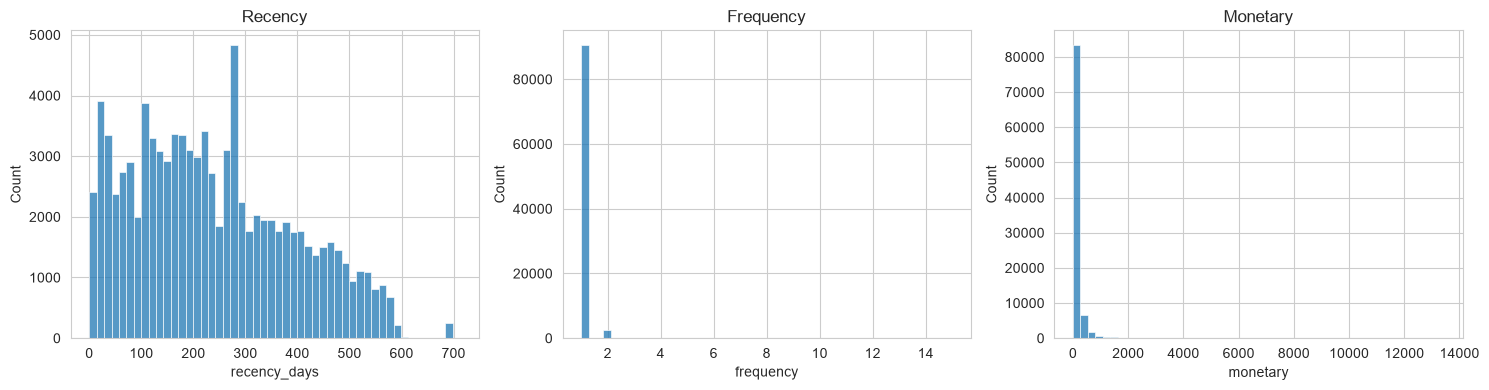

frequency
1    90557
2     2573
3      181
4       28
5        9
Name: count, dtype: int64


In [ ]:
# Kiểm tra phân phối 3 chỉ số 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm['recency_days'], bins=50, ax=axes[0]).set_title('Recency')
sns.histplot(rfm['frequency'], bins=50, ax=axes[1]).set_title('Frequency')
sns.histplot(rfm['monetary'], bins=50, ax=axes[2]).set_title('Monetary')
plt.tight_layout()
plt.savefig('../reports/figures/08_rfm_distributions.png', dpi=150)
plt.show()

print(rfm['frequency'].value_counts().head())

In [ ]:
# Log-transform Monetary
rfm['monetary_log'] = np.log1p(rfm['monetary'])

features = rfm[['recency_days', 'frequency', 'monetary_log']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

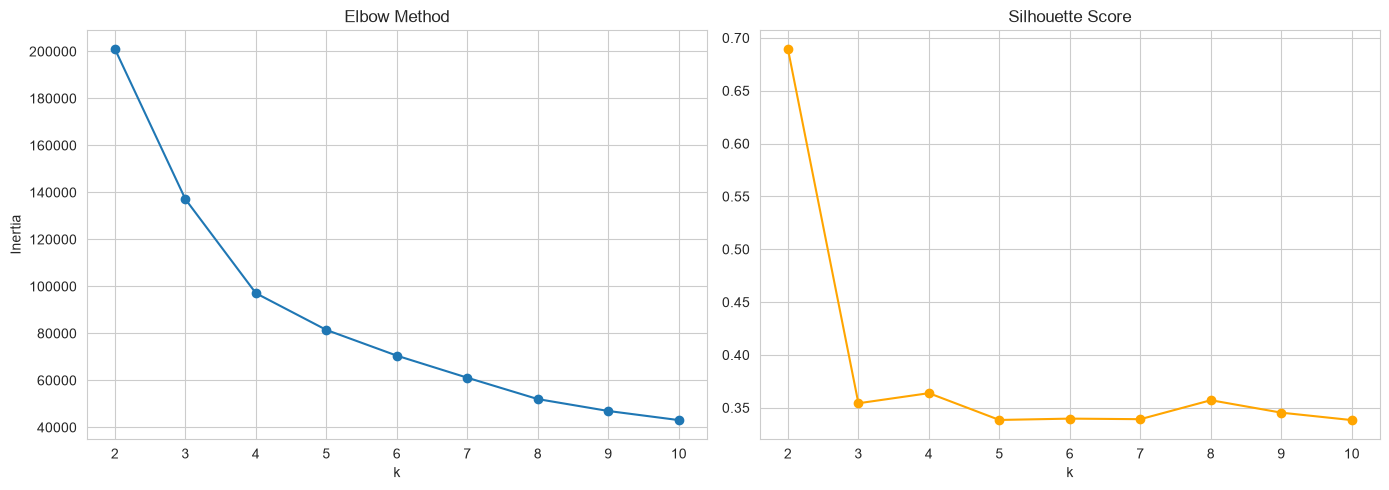

In [ ]:
inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(features_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_range), silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')
plt.tight_layout()
plt.savefig('../reports/figures/09_elbow_silhouette.png', dpi=150)
plt.show()

In [5]:
k_final = 4  # chỉnh lại theo elbow/silhouette bạn vừa quan sát

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
rfm['cluster'] = kmeans_final.fit_predict(features_scaled)

cluster_profile = rfm.groupby('cluster').agg(
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    customer_count=('customer_unique_id', 'count')
).round(1)
cluster_profile['pct_of_total'] = (cluster_profile['customer_count'] / len(rfm) * 100).round(1)

print(cluster_profile.sort_values('avg_monetary', ascending=False))

         avg_recency  avg_frequency  avg_monetary  customer_count  \
cluster                                                             
3              219.8            2.1         260.1            2801   
1              160.9            1.0         251.5           32340   
2              425.0            1.0         109.3           27322   
0              153.4            1.0          44.5           30895   

         pct_of_total  
cluster                
3                 3.0  
1                34.6  
2                29.3  
0                33.1  


In [8]:
cluster_labels = {
    3: 'Repeat Buyers',          # 3.0% — đã quay lại, ưu tiên giữ chân/upsell, đừng để rơi vào "Lapsed"
    1: 'High-Value One-Timers',  # 34.6% — nhóm lớn nhất & giá trị cao nhất per-order, mục tiêu CHÍNH để convert thành repeat
    0: 'Low-Value Newcomers',    # 33.1% — mới, chi tiêu thấp, ưu tiên thấp hơn (ROI thấp nếu đầu tư retention)
    2: 'Lapsed / At-Risk',       # 29.3% — gần 14 tháng không quay lại, coi như đã mất, cần campaign win-back riêng
}
rfm['segment_name'] = rfm['cluster'].map(cluster_labels)

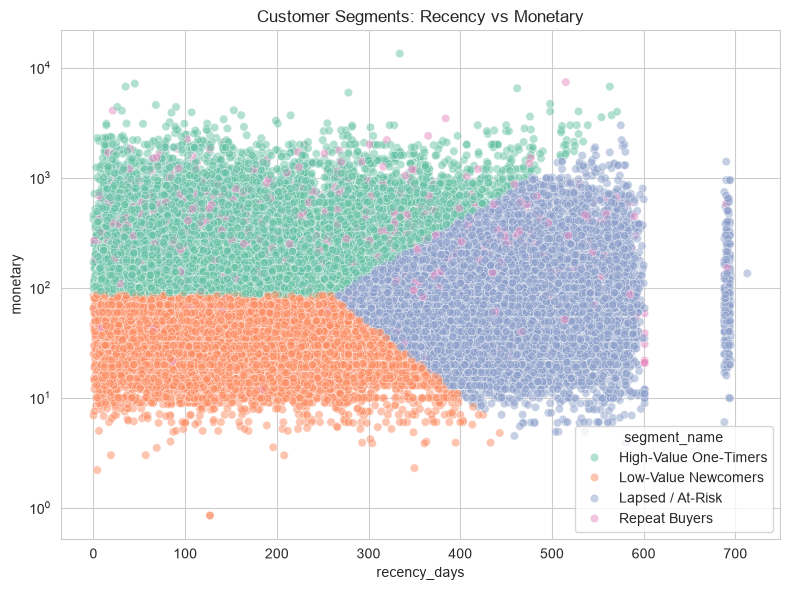

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm, x='recency_days', y='monetary', hue='segment_name', palette='Set2', alpha=0.5)
plt.yscale('log')
plt.title('Customer Segments: Recency vs Monetary')
plt.tight_layout()
plt.savefig('../reports/figures/10_segments_scatter.png', dpi=150)
plt.show()

rfm.to_csv('../data/processed/customer_segments.csv', index=False)